Validation: Image accepted
Detecting paper region...
Cleaning background...
Enhancing colors...
Reducing noise...
Cropping to content...
Resizing to standard format...
✓ Pipeline complete!


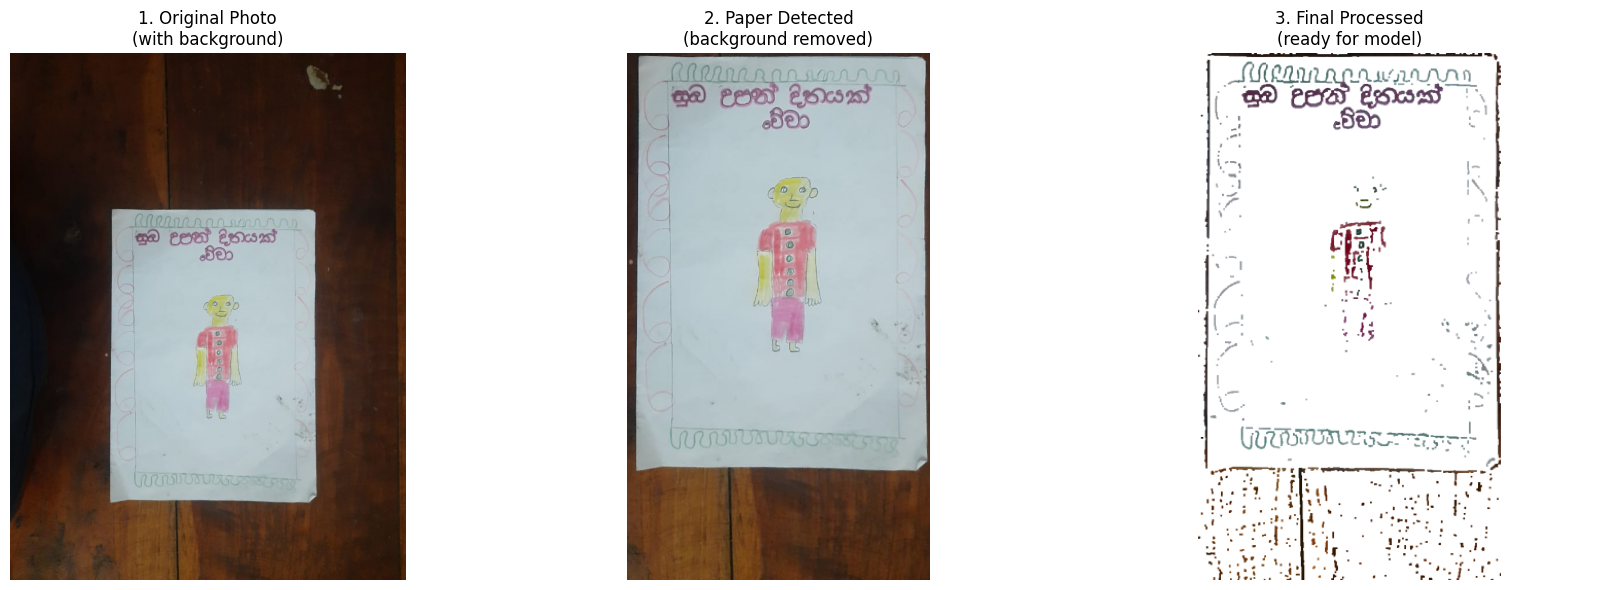


✓ Saved to: /content/processed_drawing.png


In [1]:
# -*- coding: utf-8 -*-
"""
Pipeline for extracting children's drawings from photos
Handles backgrounds (tables, walls, etc.) and isolates the paper/drawing
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap=None):
    plt.figure(figsize=(6,6))
    plt.imshow(img if cmap is None else img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def validate_image(img):
    """Validate uploaded photo quality"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    if h < 400 or w < 400:
        return False, "Image resolution too low (min 400x400)"

    mean_brightness = np.mean(gray)
    if mean_brightness < 40 or mean_brightness > 220:
        return False, "Lighting conditions not suitable"

    contrast = gray.std()
    if contrast < 20:
        return False, "Low contrast - image too uniform"

    return True, "Image accepted"

def detect_paper_region(img):
    """
    Detect the paper/drawing sheet in the photo using edge detection
    This removes background (table, wall, hands, etc.)
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Use Canny edge detection to find paper boundaries
    edges = cv2.Canny(blurred, 50, 150)

    # Dilate edges to connect broken lines
    kernel = np.ones((5, 5), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=2)

    # Find contours (paper boundary)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # Find the largest rectangular contour (likely the paper)
    paper_contour = None
    max_area = 0

    for contour in contours:
        area = cv2.contourArea(contour)
        # Paper should be at least 25% of image area
        if area > 0.25 * img.shape[0] * img.shape[1]:
            # Approximate to polygon
            peri = cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, 0.02 * peri, True)

            # Look for 4-sided shapes (paper is rectangular)
            if len(approx) == 4 and area > max_area:
                max_area = area
                paper_contour = approx

    # If we found a rectangular paper, do perspective transform
    if paper_contour is not None:
        return perspective_transform(img, paper_contour)

    # Fallback: use bounding box of largest contour
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) > 0.25 * img.shape[0] * img.shape[1]:
        x, y, w, h = cv2.boundingRect(largest)
        return img[y:y+h, x:x+w]

    return None

def perspective_transform(img, contour):
    """
    Apply perspective transform to straighten the paper
    Handles photos taken at an angle
    """
    # Reshape contour points
    pts = contour.reshape(4, 2)

    # Order points: top-left, top-right, bottom-right, bottom-left
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left (smallest sum)
    rect[2] = pts[np.argmax(s)]  # bottom-right (largest sum)

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right (smallest diff)
    rect[3] = pts[np.argmax(diff)]  # bottom-left (largest diff)

    # Calculate width and height
    (tl, tr, br, bl) = rect
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = max(int(widthA), int(widthB))

    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = max(int(heightA), int(heightB))

    # Destination points for "bird's eye view"
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")

    # Calculate perspective transform matrix and apply it
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))

    return warped

def clean_background(img):
    """
    Make the paper background pure white
    Remove shadows, wrinkles, and color casts
    """
    # Convert to LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to L channel to normalize lighting
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # Merge back
    enhanced = cv2.merge((l, a, b))
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

    # Create mask for paper (light areas)
    gray = cv2.cvtColor(enhanced, cv2.COLOR_RGB2GRAY)

    # Adaptive threshold to separate paper from drawing
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21, 10
    )

    # Clean up the mask
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # Make paper areas pure white
    result = enhanced.copy()
    result[thresh == 255] = [255, 255, 255]

    return result

def enhance_drawing_colors(img):
    """
    Boost crayon/marker colors to match dataset vibrancy
    Preserve the natural hand-drawn texture
    """
    # Convert to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # Identify colored regions (actual drawing marks)
    colored_mask = s > 30  # Areas with some saturation

    # Boost saturation only in colored areas
    s_enhanced = s.copy()
    s_enhanced[colored_mask] = np.clip(s[colored_mask] * 1.3 + 15, 0, 255).astype(np.uint8)

    # Slightly darken colored strokes for better visibility
    v_enhanced = v.copy()
    v_enhanced[colored_mask] = np.clip(v[colored_mask] * 0.95, 0, 255).astype(np.uint8)

    # Merge and convert back
    enhanced_hsv = cv2.merge((h, s_enhanced, v_enhanced))
    result = cv2.cvtColor(enhanced_hsv, cv2.COLOR_HSV2RGB)

    return result

def denoise_preserving_texture(img):
    """
    Remove camera noise while keeping crayon texture
    """
    # Bilateral filter: smooths noise but preserves edges
    result = cv2.bilateralFilter(img, 9, 75, 75)
    return result

def crop_to_drawing(img):
    """
    Crop to the actual drawing content, removing excess white space
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Find all non-white pixels
    _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

    # Find bounding box of drawing content
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img

    x, y, w, h = cv2.boundingRect(coords)

    # Add 5% padding
    pad_x = int(w * 0.05)
    pad_y = int(h * 0.05)

    x = max(0, x - pad_x)
    y = max(0, y - pad_y)
    w = min(img.shape[1] - x, w + 2 * pad_x)
    h = min(img.shape[0] - y, h + 2 * pad_y)

    return img[y:y+h, x:x+w]

def resize_to_standard(img, target_size=512):
    """
    Resize to match dataset format (e.g., 512x512)
    Maintains aspect ratio, adds white padding
    """
    h, w = img.shape[:2]

    # Calculate scale to fit within target
    scale = min(target_size / w, target_size / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # Resize with high-quality interpolation
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Create white canvas
    canvas = np.full((target_size, target_size, 3), 255, dtype=np.uint8)

    # Center the drawing
    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return canvas

def full_pipeline(image_path, target_size=512):
    """
    Complete pipeline: Photo with background -> Clean drawing

    Steps:
    1. Validate image quality
    2. Detect paper region (remove table/wall background)
    3. Clean paper background (remove shadows/wrinkles)
    4. Enhance drawing colors
    5. Remove noise
    6. Crop to drawing content
    7. Resize to standard format
    """
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Cannot read image from {image_path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Validate
    valid, msg = validate_image(img)
    print(f"Validation: {msg}")
    if not valid:
        return None

    # Step 1: Detect and extract paper from photo background
    print("Detecting paper region...")
    paper = detect_paper_region(img)
    if paper is None:
        print("Warning: Could not detect paper boundary, using full image")
        paper = img

    # Step 2: Clean the paper background
    print("Cleaning background...")
    cleaned = clean_background(paper)

    # Step 3: Enhance colors
    print("Enhancing colors...")
    enhanced = enhance_drawing_colors(cleaned)

    # Step 4: Denoise
    print("Reducing noise...")
    denoised = denoise_preserving_texture(enhanced)

    # Step 5: Crop to drawing
    print("Cropping to content...")
    cropped = crop_to_drawing(denoised)

    # Step 6: Resize to standard format
    print("Resizing to standard format...")
    final = resize_to_standard(cropped, target_size)

    print("✓ Pipeline complete!")
    return img, paper, final

# Example usage
if __name__ == "__main__":
    # Process a photo containing a children's drawing
    result = full_pipeline("wood bg1.jpeg", target_size=512)

    if result:
        original, paper_detected, final = result

        # Display results
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(original)
        axes[0].set_title("1. Original Photo\n(with background)")
        axes[0].axis("off")

        axes[1].imshow(paper_detected)
        axes[1].set_title("2. Paper Detected\n(background removed)")
        axes[1].axis("off")

        axes[2].imshow(final)
        axes[2].set_title("3. Final Processed\n(ready for model)")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

        # Save result
        final_bgr = cv2.cvtColor(final, cv2.COLOR_RGB2BGR)
        cv2.imwrite("/content/processed_drawing.png", final_bgr)
        print(f"\n✓ Saved to: /content/processed_drawing.png")